# Demonstração: k-NN para diagnóstico de câncer

Nesta demonstração, seguimos um fluxo simples e alinhado à Aula 4. O objetivo é treinar um classificador k-NN para distinguir casos benignos e malignos de nódulos na mama, observar o efeito do hiperparâmetro `k` e visualizar métricas e gráficos básicos.

## 1. Importações e configuração
Aqui carregamos as bibliotecas necessárias e definimos os caminhos dos arquivos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

%matplotlib inline

DATA_PATH = Path('datasets/breast-cancer-wisconsin.data.txt')

## 2. Carregar dados
O conjunto de dados Câncer de mama Wisconsin vem sem cabeçalhos. Vamos definir os nomes das colunas e remover o identificador.

In [2]:
col_names = [
    'Identificador',
    'Espessura_aglomerado',
    'Uniformidade_tamanho_celula',
    'Uniformidade_forma_celula',
    'Adesao_marginal',
    'Tamanho_celula_epitelial',
    'Nucleos_nus',
    'Cromatina_suave',
    'Nucleolos_normais',
    'Mitoses',
    'Classe'
]

df = pd.read_csv(DATA_PATH, header=None, names=col_names)

df.drop('Identificador', axis=1, inplace=True)

df.head()

,Espessura_aglomerado,Uniformidade_tamanho_celula,Uniformidade_forma_celula,Adesao_marginal,Tamanho_celula_epitelial,Nucleos_nus,Cromatina_suave,Nucleolos_normais,Mitoses,Classe
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


## 3. Limpeza básica
A coluna `Nucleos_nus` possui valores ausentes representados como `?`. Vamos converter para número e tratar ausências depois.

In [3]:
df['Nucleos_nus'] = pd.to_numeric(df['Nucleos_nus'], errors='coerce')

df.isna().sum()

Espessura_aglomerado            0
Uniformidade_tamanho_celula     0
Uniformidade_forma_celula       0
Adesao_marginal                 0
Tamanho_celula_epitelial        0
Nucleos_nus                    16
Cromatina_suave                 0
Nucleolos_normais               0
Mitoses                         0
Classe                          0
dtype: int64

## 4. Separar variáveis e alvo
A variável-alvo é `Classe` (2 = benigno, 4 = maligno).

In [4]:
X = df.drop('Classe', axis=1)
y = df['Classe']

X.head()

,Espessura_aglomerado,Uniformidade_tamanho_celula,Uniformidade_forma_celula,Adesao_marginal,Tamanho_celula_epitelial,Nucleos_nus,Cromatina_suave,Nucleolos_normais,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


## 5. Separar treino e teste
Usamos estratificação para manter a proporção das classes.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

X_train.shape, X_test.shape

((559, 9), (140, 9))

## 6. Imputar valores ausentes
Usamos a mediana do treino para preencher valores faltantes em treino e teste.

In [6]:
for col in X_train.columns:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

X_train.isna().sum()

Espessura_aglomerado           0
Uniformidade_tamanho_celula    0
Uniformidade_forma_celula      0
Adesao_marginal                0
Tamanho_celula_epitelial       0
Nucleos_nus                    0
Cromatina_suave                0
Nucleolos_normais              0
Mitoses                        0
dtype: int64

## 7. Padronização
k-NN é sensível à escala, então padronizamos as variáveis.

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 8. Linha de base simples
Calculamos a acurácia de sempre prever a classe majoritária no treino como linha de base.

In [8]:
majority_class = y_train.value_counts().idxmax()
null_accuracy = (y_test == majority_class).mean()

print(f"Acurácia da linha de base (classe majoritária): {null_accuracy:.4f}")

Acurácia da linha de base (classe majoritária): 0.6571


## 9. Treinar k-NN (k=3)
Este é o ponto de partida do modelo.

In [9]:
knn_3 = KNeighborsClassifier(n_neighbors=3)
knn_3.fit(X_train, y_train)

y_pred_3 = knn_3.predict(X_test)
acc_3 = accuracy_score(y_test, y_pred_3)

print(f"Acurácia k=3: {acc_3:.4f}")

Acurácia k=3: 0.9571


## 10. Testar diferentes valores de k
Observamos como o erro muda com o hiperparâmetro `k`.

Melhor k (por acurácia no teste): 9


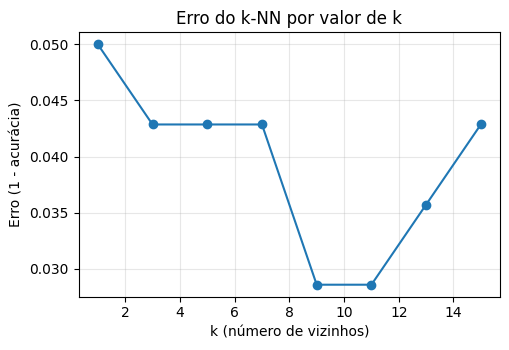

In [10]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
errors = []
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    errors.append(1 - acc)

best_idx = int(np.argmax(accuracies))
best_k = k_values[best_idx]
print(f"Melhor k (por acurácia no teste): {best_k}")

plt.figure(figsize=(5.2, 3.6))
plt.plot(k_values, errors, marker='o')
plt.xlabel('k (número de vizinhos)')
plt.ylabel('Erro (1 - acurácia)')
plt.title('Erro do k-NN por valor de k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Matriz de confusão e relatório
Agora avaliamos o melhor valor de `k`.

              precision    recall  f1-score   support

           2       1.00      0.96      0.98        92
           4       0.92      1.00      0.96        48

    accuracy                           0.97       140
   macro avg       0.96      0.98      0.97       140
weighted avg       0.97      0.97      0.97       140



<Figure size 420x360 with 0 Axes>

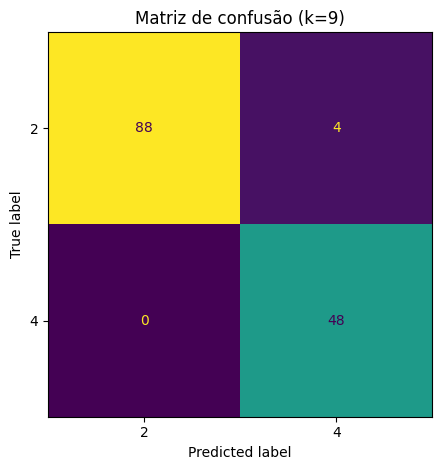

In [11]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)

y_pred_best = knn_best.predict(X_test)

print(classification_report(y_test, y_pred_best))

plt.figure(figsize=(4.2, 3.6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, colorbar=False)
plt.title(f"Matriz de confusão (k={best_k})")
plt.tight_layout()
plt.show()

## 12. Curva ROC e AUC
Usamos a classe `4` (maligno) como positiva.

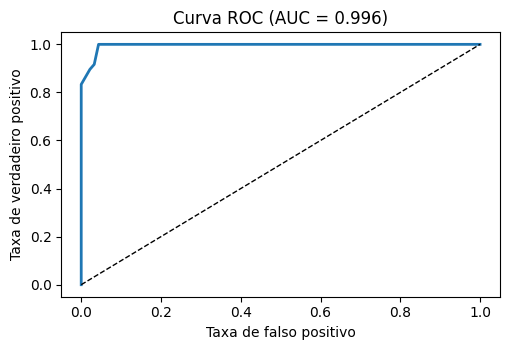

In [12]:
proba = knn_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba, pos_label=4)
roc_auc = roc_auc_score(y_test, proba)

plt.figure(figsize=(5.2, 3.6))
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Taxa de falso positivo')
plt.ylabel('Taxa de verdadeiro positivo')
plt.title(f'Curva ROC (AUC = {roc_auc:.3f})')
plt.tight_layout()
plt.show()